##CISC5790 Group Project

**Members:** Chris Jones, Muhammad Zaid Maqsood, Tiger Hou

**Research topic:** We are looking at the performances of each MLB team from the most recent 10 years, and building a model predicting their standing using their annual payroll amount and Win Above Replacement (WAR) indicator.

**Data Resource:**
* Financial Data extracted from Spotrac (spotrac.com)
* Performance Data extracted from FanGraphs (fangraphs.com)

**Data and Analyses Overview:**
* The data are drawn from 2015 to 2025 with the exception of the shortened season 2020 due to the global pandemic. Input data consists of Payroll amount, Wins Above Replacement (WAR) indicator, Winning Percentage, and dichotomous indicators showing if a team won the division title, appeared in playoff, appeared in World Series, and/or won the World Series for a specific year.
* Linear Regression and Random Forest (RF) are used in this study.

**ReadMe:**
* The user needs to upload the data in the first section. Please make sure the input data is selected correctly.

* If the upload is unsuccessful, please navigate to the Runtime tab at the top and click Disconnect and Delete Runtime before re-running the block

**Function for uploading clean CSV files everytime**

In [35]:
import io
import os
import glob
import numpy as np
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

**Uploading and Data Preprocessing**


In [36]:
# Define function to Delete any existing files that start with base_name e.g. mlb_finance_data_1.csv, mlb_finance_data_1 (1).csv, etc.
# Prompts user to upload the CSV again
# Loads the uploaded CSV into a pandas DataFrame and returns it

def upload_clean_csv(base_name="mlb_finance_data_1"):
    # 1) Remove previous versions
    pattern = f"{base_name}*"
    for f in glob.glob(pattern):
        try:
            os.remove(f)
            print(f"Removed old file: {f}")
        except OSError as e:
            print(f"Could not remove {f}: {e}")

    # 2) Upload fresh file
    print("Please upload the CSV file now...")
    uploaded = files.upload()

    # 3) Read the first uploaded file
    filename = list(uploaded.keys())[0]
    print(f"Loaded file from disk as: {filename}")

    df = pd.read_csv(io.BytesIO(uploaded[filename]))
    return df

In [37]:
# File Upload (function defined in previous block to avoid file duplication at runtime)
df = upload_clean_csv("mlb_finance_data_1")

# Data Cleaning
df['Total_Payroll'] = (
    df['Total_Payroll']
    .replace('[\$,]', '', regex=True)
    .astype(float)
)

# Exclude 2020 season if present
if "Season" in df.columns:
    df = df[df["Season"] != 2020]

# Normalize scale if needed
if df['Win_%'].max() > 1.0:
    df['Win_%'] = df['Win_%'] / 100.0

# Feature Engineering (additional metrics)
# Total wins in a 162-game season
df['wins'] = (df['Win_%'] * 162).round(0)

# Cost per WAR in million (lower val higher efficient spending)
df['cost_per_WAR_m'] = np.where(df['WAR'] > 0, ((df['Total_Payroll'] / df['WAR'])/ 1000000).round(2), np.nan)

# Cost per win in million (higher val higher return)
df['cost_per_win_m'] = np.where(df['wins'] > 0, ((df['Total_Payroll'] / df['wins'])/ 1000000).round(2), np.nan)

# Payroll quartiles for stratification (low → high spenders categorization)
df['payroll_quartile'] = pd.qcut(df['Total_Payroll'], 4, labels=['Low', 'Mid-Low', 'Mid-High', 'High'])

# Identify over and under-performers using below-median payroll but above-median Win_% (over-performers) and vice versa scenarios (value for money metric)
payroll_median = df['Total_Payroll'].median()
win_median = df['Win_%'].median()

conditions = [(df['Total_Payroll'] < payroll_median) & (df['Win_%'] >= win_median), (df['Total_Payroll'] >= payroll_median) & (df['Win_%'] < win_median)]
choices = ['Over-performer', 'Under-performer']
df['performance_tag'] = np.select(conditions, choices, default='Expected')

# top 2 performers each season
top_over = (df[df['performance_tag'] == 'Over-performer'].sort_values(['Season', 'Win_%'], ascending=[True, False]).groupby('Season').head(2)[['Season', 'Team', 'cost_per_win_m', 'Win_%']])
print("Top 2 Over-Performers Per Season:")
print(top_over.to_string(index=False))

# bottom 2 worst performers each season
bottom_under = (df[df['performance_tag'] == 'Under-performer'].sort_values(['Season', 'Win_%'], ascending=[True, True]).groupby('Season').head(2)[['Season', 'Team', 'cost_per_win_m', 'Win_%']])
print("\nLowest 2 Under-Performers Per Season:")
print(bottom_under.to_string(index=False))

df = df[['Team', 'Season', 'Total_Payroll', 'WAR', 'P_WAR', 'PP_WAR', 'Win_%',"division_winner", "playoff_appearance", "world_series", "world_series_winner",
         'wins', 'cost_per_WAR_m', 'cost_per_win_m', 'payroll_quartile', 'performance_tag']]
print(df.head())


Removed old file: mlb_finance_data_1.csv
Please upload the CSV file now...


<>:7: SyntaxWarning: invalid escape sequence '\$'
<>:7: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_250/2246318468.py:7: SyntaxWarning: invalid escape sequence '\$'
  .replace('[\$,]', '', regex=True)


Saving mlb_finance_data_1.csv to mlb_finance_data_1.csv
Loaded file from disk as: mlb_finance_data_1.csv
Top 2 Over-Performers Per Season:
 Season                 Team  cost_per_win_m  Win_%
   2015  St. Louis Cardinals            1.21  0.617
   2015   Pittsburgh Pirates            0.90  0.605
   2016         Chicago Cubs            1.12  0.640
   2016  Cleveland Guardians            0.91  0.584
   2017  Cleveland Guardians            1.22  0.630
   2017       Houston Astros            1.23  0.623
   2018    Oakland Athletics            0.71  0.599
   2018    Milwaukee Brewers            0.95  0.586
   2019    Oakland Athletics            0.95  0.599
   2019       Tampa Bay Rays            0.89  0.593
   2021 San Francisco Giants            1.20  0.660
   2021       Tampa Bay Rays            0.60  0.617
   2022  Cleveland Guardians            0.46  0.568
   2022     Seattle Mariners            1.01  0.568
   2023    Baltimore Orioles            0.64  0.623
   2023       Tampa Bay Rays 

**Descriptive Statistics and Correlation**

In [38]:
# Payroll statistics per team across seasons
payroll_stats = df.groupby('Team')['Total_Payroll'].describe()
print('Payroll statistics per team across seasons:\n',payroll_stats)

# WAR statistics per team
war_stats = df.groupby('Team')['WAR'].describe()
print('WAR statistics per team:\n',war_stats)

# Correlation between Payroll, WAR, and Winning Percentage
corr_matrix=df[['Total_Payroll', 'WAR', 'Win_%']].corr()
print("\nCorrelation matrix (Payroll, WAR, Win_%):\n", corr_matrix)

pairs = [('Total_Payroll', 'WAR'), ('Total_Payroll', 'Win_%'), ('WAR', 'Win_%')]
print("\nPearson Correlations with p-values:\n")
for x, y in pairs:
    r, p = pearsonr(df[x], df[y])
    print(f"{x} ↔ {y}: r = {r:.4f}, p = {p:.4e}")

# Playoff rate by payroll quartile
playoff_by_quartile = df.groupby('payroll_quartile')['playoff_appearance'].mean()
print("\nPlayoff appearance rate by payroll quartile:")
print(playoff_by_quartile)

# Over vs under-performers count
print("\n Distribution based on performance tags across all seasons:")
print(df['performance_tag'].value_counts())
print()


Payroll statistics per team across seasons:
                        count         mean           std          min  \
Team                                                                   
Arizona Diamondbacks    10.0  111438511.9  3.427368e+07   70762833.0   
Atlanta Braves          10.0  149761568.9  4.786180e+07   87622648.0   
Baltimore Orioles       10.0   99782578.0  4.501371e+07   30221166.0   
Boston Red Sox          10.0  191850282.3  2.111404e+07  162324847.0   
Chicago Cubs            10.0  165937228.7  3.600715e+07  116654522.0   
Chicago White Sox       10.0  117058454.8  3.998070e+07   59000000.0   
Cincinnati Reds         10.0  106471413.8  1.661505e+07   86374500.0   
Cleveland Guardians     10.0   85389033.5  2.880342e+07   42310000.0   
Colorado Rockies        10.0  127535945.5  2.338260e+07   98261171.0   
Detroit Tigers          10.0  133561763.3  3.790914e+07   80398600.0   
Houston Astros          10.0  155550727.3  5.370779e+07   69064200.0   
Kansas City Royals 

/tmp/ipykernel_250/1598188518.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  playoff_by_quartile = df.groupby('payroll_quartile')['playoff_appearance'].mean()


**Preliminary Visualization of Payroll and WAR**

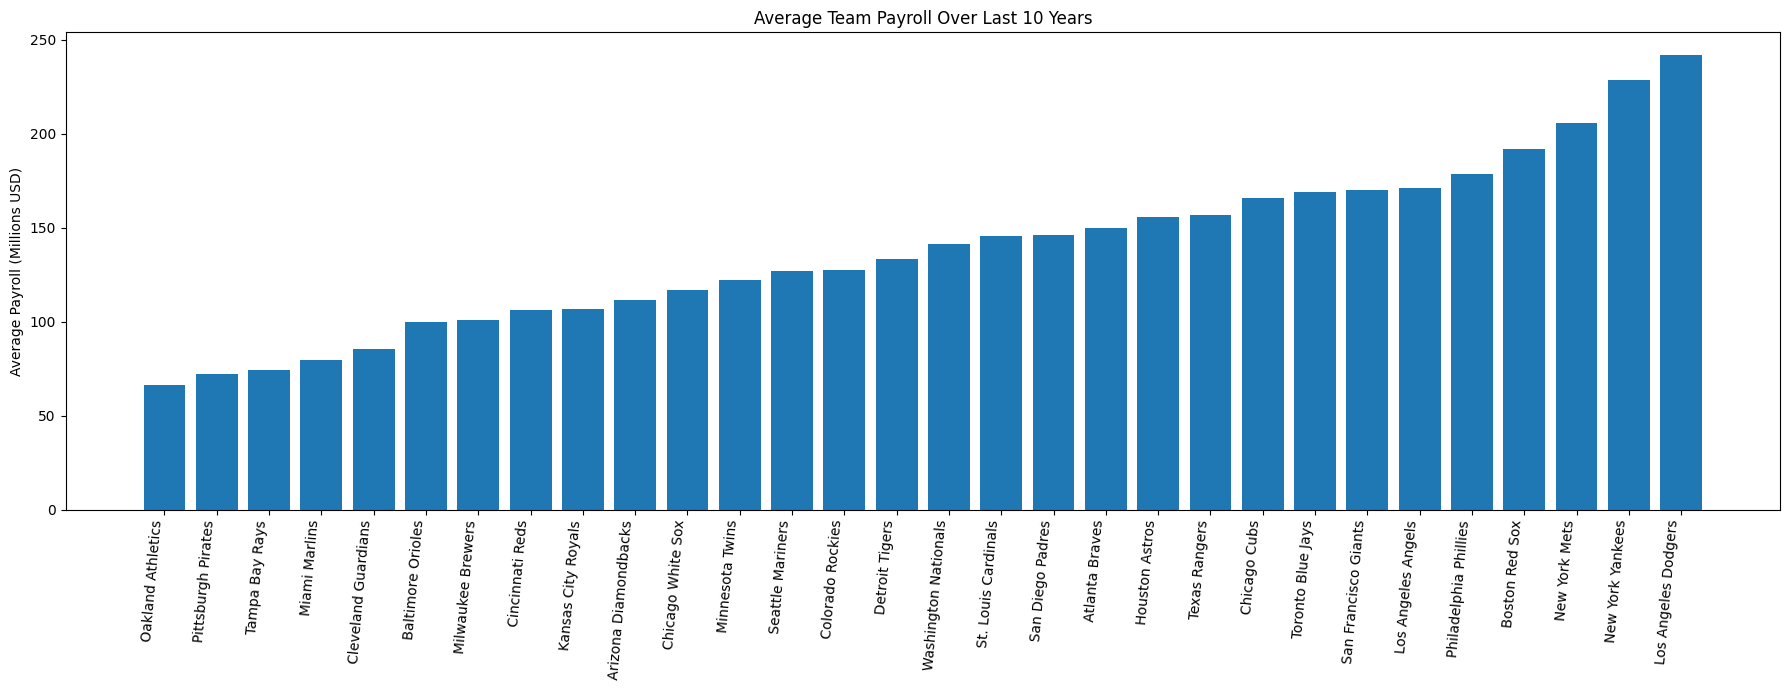

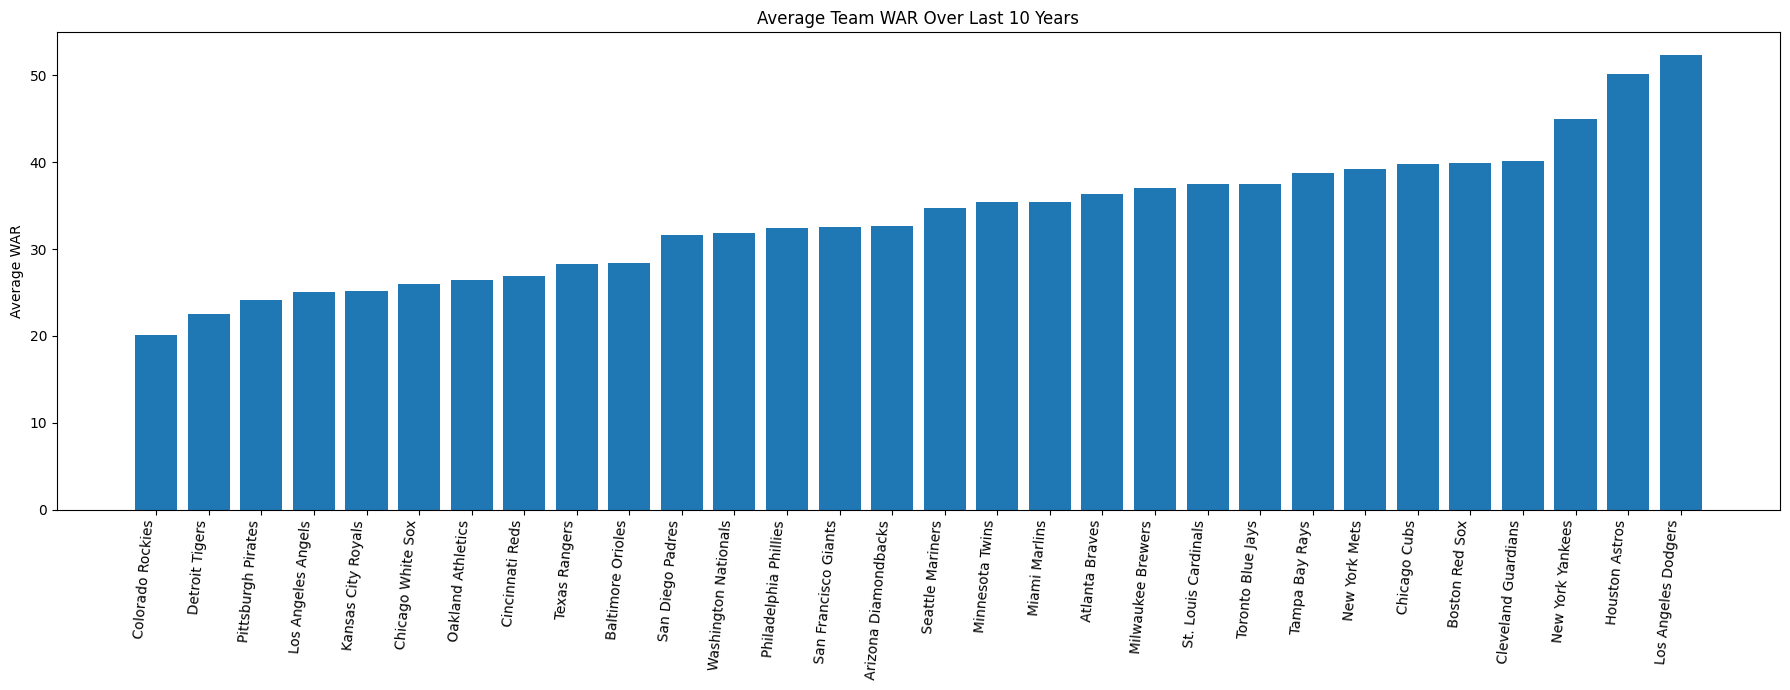

In [39]:
# Average payroll per team (in millions)
avg_payroll = df.groupby('Team')['Total_Payroll'].mean().sort_values()
avg_payroll_m = avg_payroll / 1000000  # Convert to millions

plt.figure(figsize=(18,7))
plt.bar(avg_payroll_m.index, avg_payroll_m.values)
plt.ylabel("Average Payroll (Millions USD)")
plt.title("Average Team Payroll Over Last 10 Years")
plt.xticks(rotation=85, ha='right')
plt.tight_layout()
plt.show()

# Average WAR per team
war = df.groupby('Team')['WAR'].mean().sort_values()

plt.figure(figsize=(18,7))
plt.bar(war.index, war.values)
plt.ylabel("Average WAR")
plt.title("Average Team WAR Over Last 10 Years")
plt.xticks(rotation=85, ha='right')
plt.tight_layout()
plt.show()


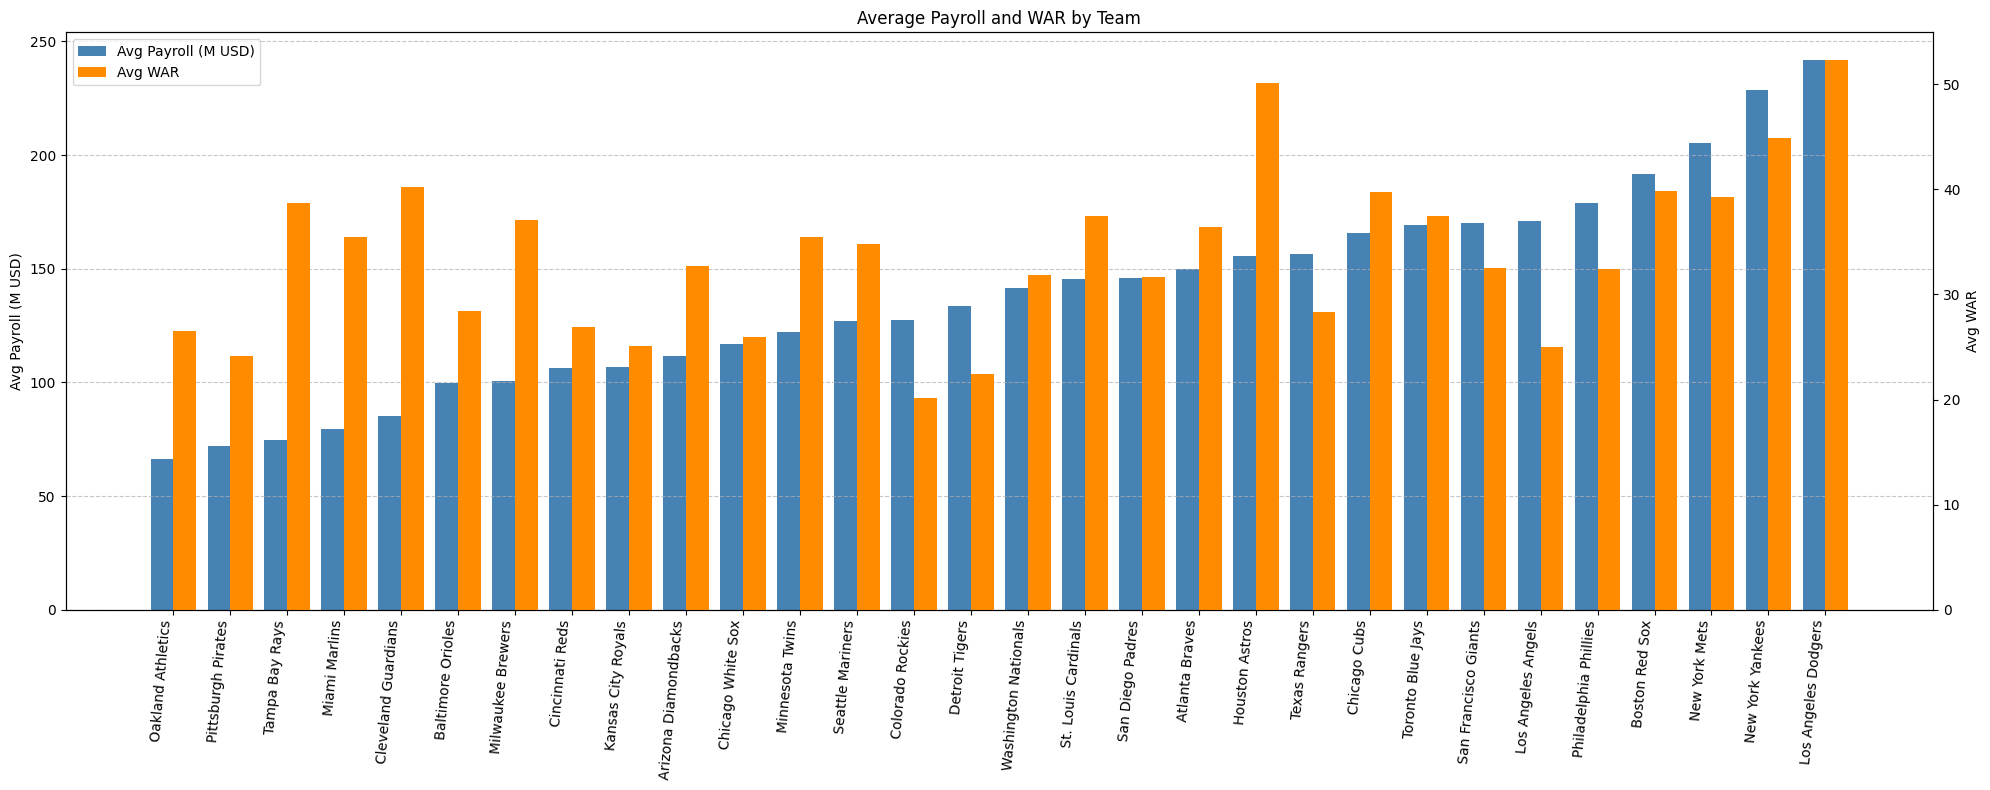

In [40]:
# Average Win_% per team (×100)
win_pct = df.groupby('Team')["Win_%"].mean() * 100

# Align both series by index for combined plotting
combined = (pd.DataFrame({"Payroll_M": avg_payroll_m, "WAR": war}).sort_values("Payroll_M"))

teams = combined.index
x = np.arange(len(teams))
width = 0.4

fig, ax1 = plt.subplots(figsize=(20,8))
ax2 = ax1.twinx()

# Bars for payroll and WAR
ax1.bar(x - width/2, combined["Payroll_M"], width, color='steelblue', label="Avg Payroll (M USD)")
bars_war = ax2.bar(x + width/2, combined["WAR"], width, color='darkorange', label="Avg WAR")

# X-axis, labels, title
ax1.set_xticks(x)
ax1.set_xticklabels(teams, rotation=85, ha='right')
ax1.set_ylabel("Avg Payroll (M USD)")
ax2.set_ylabel("Avg WAR")
plt.title("Average Payroll and WAR by Team")

ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Legend
handles = [ax1.containers[0], bars_war]
labels = ["Avg Payroll (M USD)", "Avg WAR"]
plt.legend(handles, labels, loc='upper left')

plt.tight_layout()
plt.show()

**Regression Analysis Model 1**

In [41]:
# Model 1: OLS Regression on Win_% vs Total_Payroll + WAR (Combine)

# Prepare features and target
X_full = df[['Total_Payroll', 'WAR']]
y = df['Win_%']

# Add constant for statsmodels
X_full_const = sm.add_constant(X_full)

# Fit statsmodels OLS
ols_full = sm.OLS(y, X_full_const).fit()

# Display regression table with p-values
print("\nModel 1 with OLS Regression: Win_% vs Total_Payroll + WAR\n")
print(ols_full.summary())

# SSE (Sum of Squared Errors)
preds_full = ols_full.predict(X_full_const)
SSE_full = np.sum((y - preds_full) ** 2)
print("SSE (Full model):", SSE_full)



Model 1 with OLS Regression: Win_% vs Total_Payroll + WAR

                            OLS Regression Results                            
Dep. Variable:                  Win_%   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.722
Method:                 Least Squares   F-statistic:                     388.3
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           1.33e-83
Time:                        22:55:28   Log-Likelihood:                 528.63
No. Observations:                 300   AIC:                            -1051.
Df Residuals:                     297   BIC:                            -1040.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

In [42]:
# Computing in-sample (training) fit by evaluating predictions on the same data used to train the model
# Model 1 with Normalization: OLS Regression on Win_% vs Total_Payroll + WAR (Combine)
scaler = StandardScaler()

# Fit-transform WAR and Payroll into normalized versions
df[['Total_Payroll_norm', 'WAR_norm']] = scaler.fit_transform(df[['Total_Payroll', 'WAR']])

# Prepare features and target
X_norm = df[['Total_Payroll_norm', 'WAR_norm']]
y = df['Win_%']

# Add constant for statsmodels
X_norm_const = sm.add_constant(X_norm)
ols_norm = sm.OLS(y, X_norm_const).fit()

# Display regression table with p-values
print("\nModel 1 with OLS Regression after Normalization`: Win_% vs Total_Payroll + WAR\n")
print(ols_norm.summary())

# SSE (Sum of Squared Errors)
preds_full = ols_norm.predict(X_norm_const)
SSE_full = np.sum((y - preds_full) ** 2)
print("SSE (Full model):", SSE_full)



Model 1 with OLS Regression after Normalization`: Win_% vs Total_Payroll + WAR

                            OLS Regression Results                            
Dep. Variable:                  Win_%   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.722
Method:                 Least Squares   F-statistic:                     388.3
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           1.33e-83
Time:                        22:55:28   Log-Likelihood:                 528.63
No. Observations:                 300   AIC:                            -1051.
Df Residuals:                     297   BIC:                            -1040.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------

**Regression Analysis Model 2**

In [43]:
# Model 2: OLS Regression on Win_% vs WAR

# Prepare features and target
X_war = df[['WAR']]
y = df['Win_%']

# Add constant for statsmodels
X_war_const = sm.add_constant(X_war)

# Fit statsmodels OLS
ols_war = sm.OLS(y, X_war_const).fit()

# Display regression table with p-values
print("\nModel 2 with OLS Regression: Win_% vs WAR \n")
print(ols_war.summary())

# SSE (Sum of Squared Errors)
preds_war = ols_war.predict(X_war_const)
SSE_war = np.sum((y - preds_war) ** 2)
print("SSE (WAR-only model):", SSE_war)



Model 2 with OLS Regression: Win_% vs WAR 

                            OLS Regression Results                            
Dep. Variable:                  Win_%   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.722
Method:                 Least Squares   F-statistic:                     776.5
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           5.56e-85
Time:                        22:55:28   Log-Likelihood:                 528.25
No. Observations:                 300   AIC:                            -1052.
Df Residuals:                     298   BIC:                            -1045.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const  

**Regression Analysis Model 3**

In [44]:
# Model 3: OLS Regression on Win_% vs Total_Payroll

# Prepare features and target
X_payroll = df[['Total_Payroll']]
y = df['Win_%']

# Add constant for statsmodels
X_payroll_const = sm.add_constant(X_payroll)

# Fit statsmodels OLS
ols_payroll = sm.OLS(y, X_payroll_const).fit()

# Display regression table with p-values
print("\nModel 3 with OLS Regression: Win_% vs Total_Payroll \n")
print(ols_payroll.summary())

# SSE (Sum of Squared Errors)
preds_payroll = ols_payroll.predict(X_payroll_const)
SSE_payroll = np.sum((y - preds_payroll) ** 2)
print("SSE (Payroll-only model):", SSE_payroll)



Model 3 with OLS Regression: Win_% vs Total_Payroll 

                            OLS Regression Results                            
Dep. Variable:                  Win_%   R-squared:                       0.122
Model:                            OLS   Adj. R-squared:                  0.119
Method:                 Least Squares   F-statistic:                     41.24
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           5.31e-10
Time:                        22:55:28   Log-Likelihood:                 355.31
No. Observations:                 300   AIC:                            -706.6
Df Residuals:                     298   BIC:                            -699.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

**PREDICTED WINS & RANKINGS**

In [45]:
# Use WAR-only model for predicted win%
df['pred_win_pct'] = ols_war.predict(X_war_const)
df['pred_wins'] = (df['pred_win_pct'] * 162).round().astype(int)
df['actual_wins'] = (df['Win_%'] * 162).round().astype(int)

# Rank teams within each season (1 = best record)
df['actual_rank'] = df.groupby('Season')['actual_wins'].rank(ascending=False).astype(int)
df['pred_rank'] = df.groupby('Season')['pred_wins'].rank(ascending=False).astype(int)

predicted = df[['Team','Season','actual_wins','pred_wins','actual_rank','pred_rank']]

predicted.to_csv('Predicted_Actual_FullList.csv', index=False)
from google.colab import files
files.download('Predicted_Actual_FullList.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**T-test: Predicted vs Actual Ranking**

In [46]:
# t-test to evaluate significance of predicted ranking
from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(df['pred_rank'], df['actual_rank'])

print("Paired t-test: Predicted vs Actual Standings")
print("t-statistic:", t_stat)
print("p-value:", p_value)


Paired t-test: Predicted vs Actual Standings
t-statistic: -0.34583570133314373
p-value: 0.7297093970424372


**Prediction vs Actual Wins**

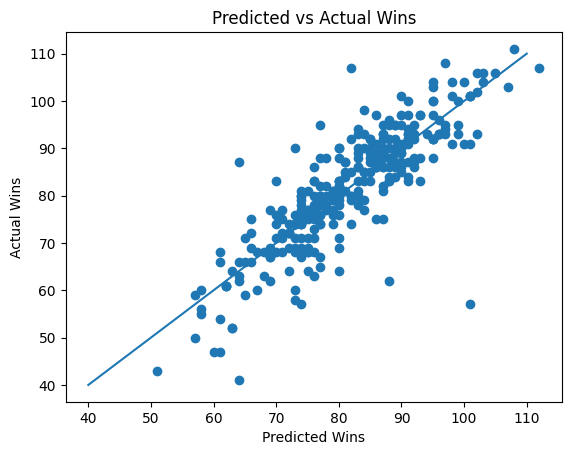

In [47]:
plt.scatter(df['pred_wins'], df['actual_wins'])
plt.xlabel("Predicted Wins")
plt.ylabel("Actual Wins")
plt.title("Predicted vs Actual Wins")
plt.plot([40,110],[40,110])  # 45 degree reference line
plt.show()


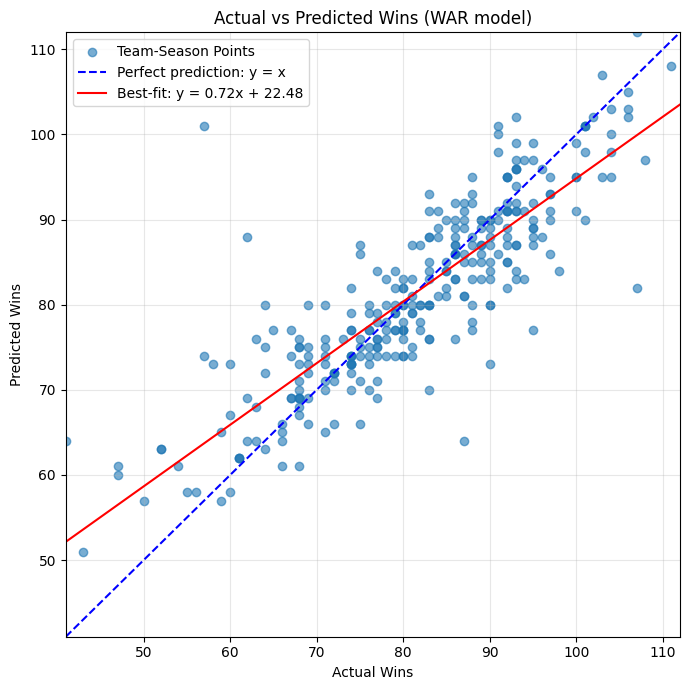

In [48]:
#Actual vs Predicted Wins + Reference & Best-Fit Lines

actual = df['actual_wins']
pred = df['pred_wins']

plt.figure(figsize=(7, 7))
plt.scatter(actual, pred, alpha=0.6, label='Team-Season Points')

# Determine common range
min_w = min(actual.min(), pred.min())
max_w = max(actual.max(), pred.max())

# Reference line: perfect prediction (y = x)
x_ref = np.linspace(min_w, max_w, 100)
y_ref = x_ref
plt.plot(x_ref, y_ref, linestyle='--', color='blue', label='Perfect prediction: y = x')

# Best-fit line: regress Predicted Wins on Actual Wins
m, b = np.polyfit(actual, pred, 1)   # slope, intercept
x_fit = np.linspace(min_w, max_w, 100)
y_fit = m * x_fit + b
plt.plot(x_fit, y_fit, color='red', label=f'Best-fit: y = {m:.2f}x + {b:.2f}')

plt.xlabel('Actual Wins')
plt.ylabel('Predicted Wins')
plt.title('Actual vs Predicted Wins (WAR model)')
plt.xlim(min_w, max_w)
plt.ylim(min_w, max_w)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Random Forest Model**


Random Forest — Predicting: Division Winner
Accuracy: 0.7866666666666666
              precision    recall  f1-score   support

           0      0.857     0.885     0.871        61
           1      0.417     0.357     0.385        14

    accuracy                          0.787        75
   macro avg      0.637     0.621     0.628        75
weighted avg      0.775     0.787     0.780        75


Random Forest — Predicting: Playoff Appearance
Accuracy: 0.8
              precision    recall  f1-score   support

           0      0.824     0.875     0.848        48
           1      0.750     0.667     0.706        27

    accuracy                          0.800        75
   macro avg      0.787     0.771     0.777        75
weighted avg      0.797     0.800     0.797        75


Random Forest — Predicting: World Series Appearance
Accuracy: 0.92
              precision    recall  f1-score   support

           0      0.944     0.971     0.958        70
           1      0.333     0.200

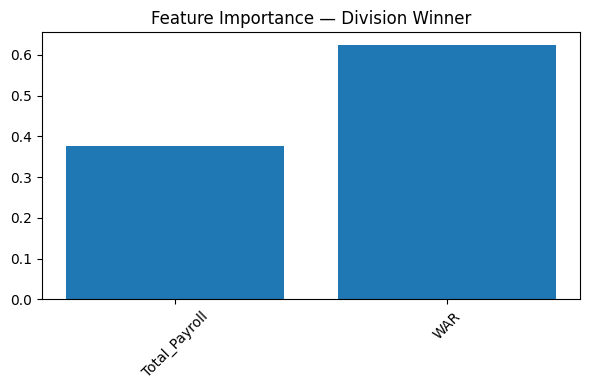

[0.31092769 0.68907231]


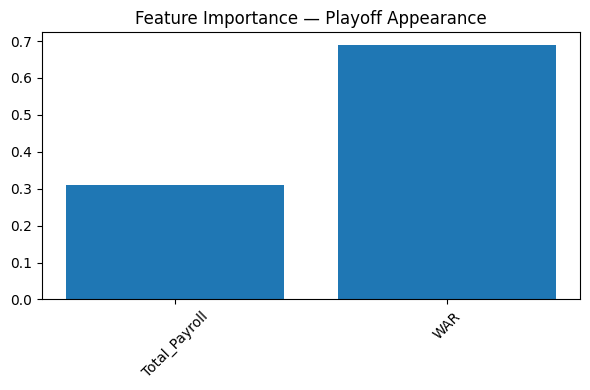

[0.41326939 0.58673061]


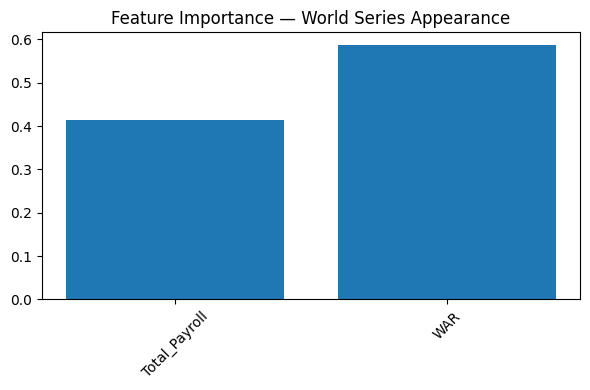

[0.38920131 0.61079869]


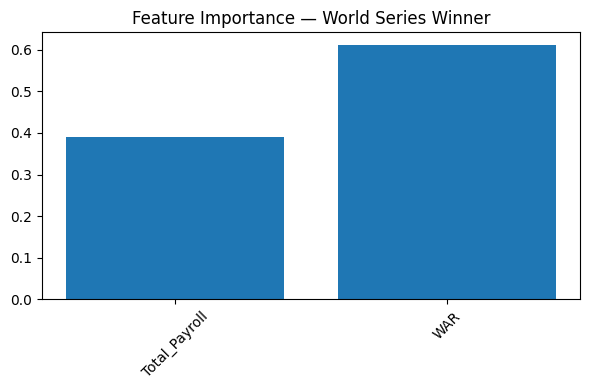

In [49]:
# Building Random Forest

# Convert boolean to integer 0/1
binary_cols = ["division_winner", "playoff_appearance", "world_series", "world_series_winner"]
for col in binary_cols:
    df[col] = df[col].astype(int)

df[binary_cols].head()

# Predictors (use payroll + WAR + components)
features = ['Total_Payroll', 'WAR']
X = df[features]

targets = {
    "Division Winner": "division_winner",
    "Playoff Appearance": "playoff_appearance",
    "World Series Appearance": "world_series",
    "World Series Winner": "world_series_winner"
}

rf_models = {}

for label, target_col in targets.items():
    print("\n==============================")
    print(f"Random Forest — Predicting: {label}")
    print("==============================")

    y = df[target_col]

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

    # Train model
    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=2,
        random_state=42,
        class_weight='balanced'
    )
    rf.fit(X_train, y_train)

    # Store model
    rf_models[label] = rf

    # Predict
    preds = rf.predict(X_test)

    # Evaluation
    print("Accuracy:", accuracy_score(y_test, preds))
    print(classification_report(y_test, preds, digits=3))

for label, model in rf_models.items():
    importances = model.feature_importances_
    print(importances)
    plt.figure(figsize=(6,4))
    plt.bar(features, importances)
    plt.title(f"Feature Importance — {label}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
